# Convertible-Bond Valuation Factors

## TL;DR

G2 materializes 44,728 investable signal-date observations across 222 dates. Conversion value,
conversion premium, and double-low have 100% coverage in the stored panel; the same-parity relative
value score has 99.12% coverage after requiring at least five bonds in a signal-date parity bucket.
All audited formulas and keys pass. These diagnostics describe factor construction and availability,
not predictive returns.


## Context & Methods

Convertible bonds combine an equity conversion option with bond-like capital protection. Raw
conversion premium is therefore strongly conditioned by conversion value, or parity. G2 first
builds absolute valuation coordinates, then compares each bond with same-date peers in a similar
parity range.

### Factor Definitions

- **Conversion value** = underlying stock close / point-in-time conversion price x 100.
- **Conversion premium** = bond close / conversion value - 1.
- **Double-low** = bond close + 100 x conversion premium.
- **Parity buckets** = below 70, 70-90, 90-100, 100-110, 110-130, and at least 130.
- **Relative premium** = bond premium - same-date parity-bucket median premium.
- **Parity value score** = negative relative premium, so a larger score is cheaper versus peers.

### Key Assumptions

The conversion price must be the point-in-time disclosed state, the underlying stock close must be
observed on the signal date, and a same-parity score requires at least five bonds in the group.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "artifacts").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from within the repository checkout.")


PROJECT_ROOT = find_project_root()
ARTIFACTS = PROJECT_ROOT / "artifacts"
ASSETS = PROJECT_ROOT / "docs" / "assets"
ASSETS.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from cb_quant.notebook_quality import build_lineage_gate

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "savefig.bbox": "tight",
})


### Load Existing G2 Artifacts


In [2]:
from cb_quant.valuation import PARITY_LABELS


def read_json(relative_path: str) -> dict:
    return json.loads((ARTIFACTS / relative_path).read_text(encoding="utf-8"))


g0_audit = read_json("G0/research_config_validation_v1.json")
g1_audit = read_json("G1/universe_audit_v1.json")
g2_audit = read_json("G2/valuation_factor_audit_v1.json")

panel_columns = [
    "signal_date",
    "ts_code",
    "close",
    "conversion_value",
    "conversion_premium",
    "double_low",
    "parity_bucket",
    "parity_group_count",
    "relative_premium_to_parity_median",
    "parity_value_score",
]
panel_files = sorted((ARTIFACTS / "G2/valuation_panel_v1").glob("year=*/part-*.parquet"))
valuation_panel = pd.concat(
    [pd.read_parquet(path, columns=panel_columns) for path in panel_files],
    ignore_index=True,
)
bucket_coverage = pd.read_parquet(ARTIFACTS / "G2/parity_bucket_coverage_v1.parquet")


## Data Quality Gate


In [3]:
lineage_gate = build_lineage_gate(
    {"G0": g0_audit, "G1": g1_audit, "G2": g2_audit}
)
formula_failures = sum(
    g2_audit[key]
    for key in [
        "conversion_value_formula_mismatches",
        "conversion_premium_formula_mismatches",
        "double_low_formula_mismatches",
        "parity_group_count_mismatches",
        "parity_group_median_mismatches",
        "relative_premium_formula_mismatches",
        "parity_value_score_sign_mismatches",
    ]
)
quality_gate = pd.DataFrame(
    [
        ["Stored G2 audit status", g2_audit["status"]],
        ["Configuration lineage gate", lineage_gate["status"]],
        ["Lineage detail", lineage_gate["detail"]],
        ["Duplicate signal-date/bond keys", g2_audit["duplicate_signal_bond_keys"]],
        ["Missing eligible keys", g2_audit["missing_eligible_keys"]],
        ["Extra ineligible keys", g2_audit["extra_ineligible_keys"]],
        ["Formula mismatches", formula_failures],
    ],
    columns=["Check", "Observed result"],
)
display(quality_gate)

,Check,Observed result
0,Stored G2 audit status,pass
1,Configuration lineage gate,pass
2,Lineage detail,Stored stage configuration fingerprints match.
3,Duplicate signal-date/bond keys,0
4,Missing eligible keys,0
5,Extra ineligible keys,0
6,Formula mismatches,0


## Results


In [4]:
coverage_by_year = pd.DataFrame(
    {
        "Year": [int(year) for year in g2_audit["valuation_coverage_by_year"]],
        "Absolute valuation (%)": [value * 100 for value in g2_audit["valuation_coverage_by_year"].values()],
        "Same-parity relative value (%)": [value * 100 for value in g2_audit["relative_value_coverage_by_year"].values()],
    }
)

distribution = valuation_panel[
    ["close", "conversion_value", "conversion_premium", "double_low", "parity_value_score"]
].quantile([0.01, 0.05, 0.50, 0.95, 0.99]).T
distribution.columns = ["P01", "P05", "Median", "P95", "P99"]
distribution.index = ["Bond close", "Conversion value", "Conversion premium", "Double-low", "Parity value score"]

correlation_columns = ["conversion_premium", "double_low", "parity_value_score"]
spearman = valuation_panel[correlation_columns].corr(method="spearman")
spearman.index = ["Conversion premium", "Double-low", "Parity value score"]
spearman.columns = spearman.index

display(coverage_by_year.round(2))
display(distribution.round(3))
display(spearman.round(3))


,Year,Absolute valuation (%),Same-parity relative value (%)
0,2018,100.0,94.56
1,2019,100.0,98.34
2,2020,100.0,99.93
3,2021,100.0,99.42
4,2022,100.0,99.27
5,2023,100.0,99.61
6,2024,100.0,99.31
7,2025,100.0,99.22
8,2026,100.0,97.90


,P01,P05,Median,P95,P99
Bond close,89.160,97.019,113.895,134.520,154.773
Conversion value,29.007,42.100,80.695,118.853,140.972
Conversion premium,0.002,0.066,0.398,1.548,2.620
Double-low,110.138,120.950,156.884,265.470,372.516
Parity value score,-1.664,-0.613,0.000,0.253,0.399


,Conversion premium,Double-low,Parity value score
Conversion premium,1.000,0.896,-0.312
Double-low,0.896,1.000,-0.397
Parity value score,-0.312,-0.397,1.000


In [5]:
bucket_summary = (
    valuation_panel.groupby("parity_bucket", observed=True)
    .agg(
        Observations=("ts_code", "size"),
        Relative_values=("parity_value_score", "count"),
        Median_conversion_value=("conversion_value", "median"),
        Median_premium=("conversion_premium", "median"),
    )
    .reindex(PARITY_LABELS)
    .reset_index()
    .rename(columns={"parity_bucket": "Parity bucket"})
)
bucket_summary["Relative coverage (%)"] = (
    bucket_summary["Relative_values"] / bucket_summary["Observations"] * 100
)
display(bucket_summary.drop(columns="Relative_values").round(2))


,Parity bucket,Observations,Median_conversion_value,Median_premium,Relative coverage (%)
0,<70,14393,57.39,0.88,100.00
1,70-90,15216,80.25,0.40,100.00
2,90-100,6446,94.65,0.25,99.75
3,100-110,4240,104.17,0.17,99.27
4,110-130,3556,116.78,0.09,98.43
5,>=130,877,141.20,0.04,66.70


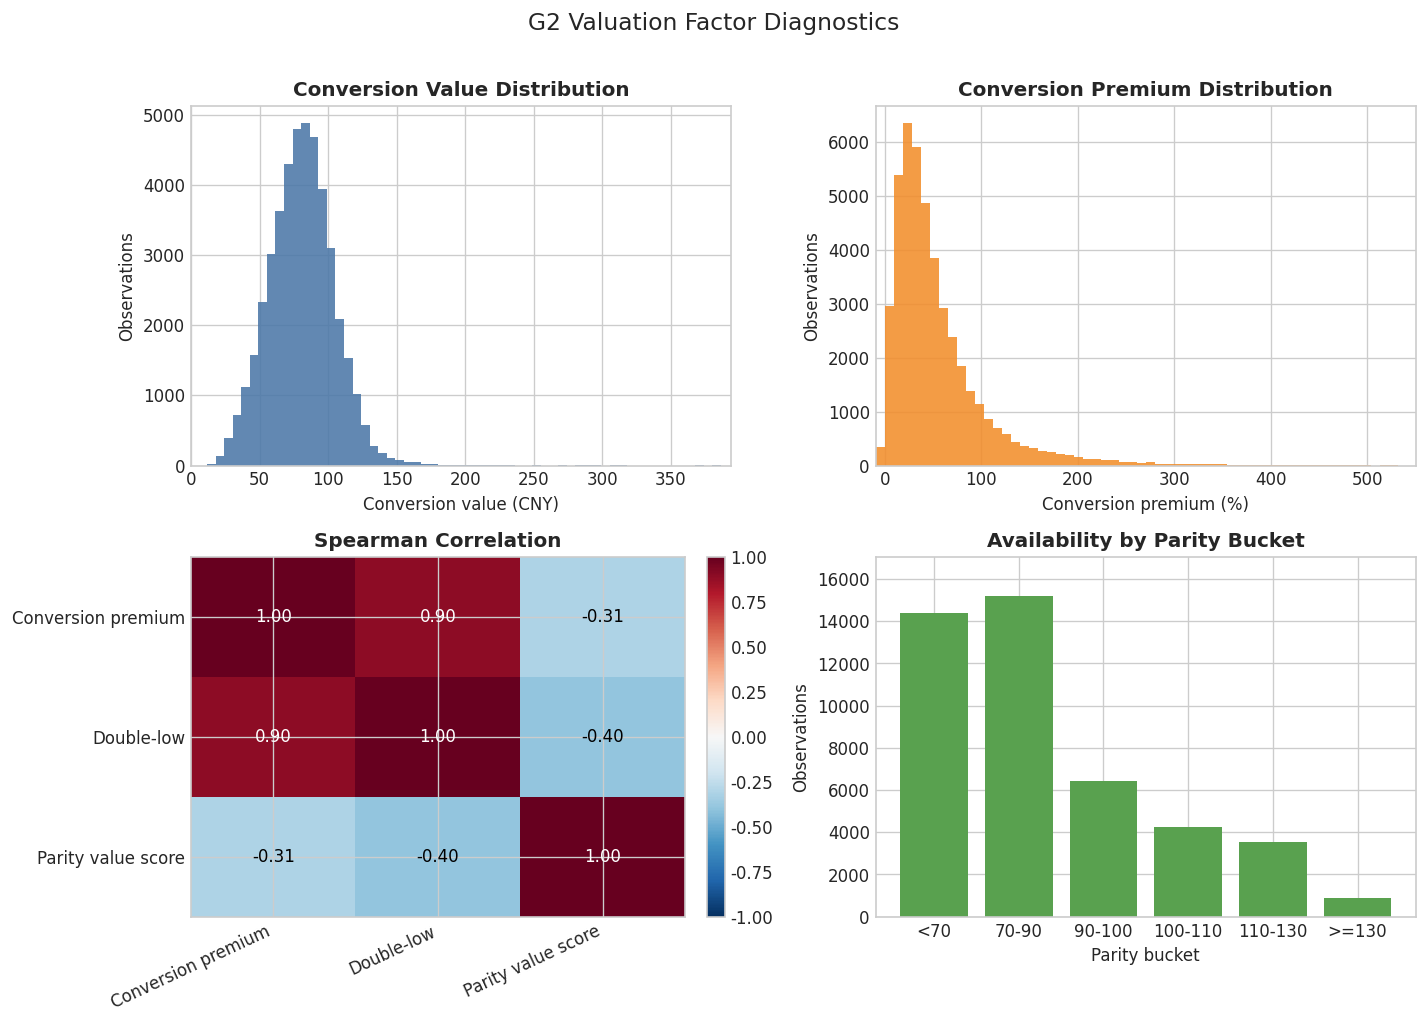

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8.4))

axes[0, 0].hist(valuation_panel["conversion_value"].dropna(), bins=60, color="#4C78A8", alpha=0.88)
axes[0, 0].set_xlim(0, valuation_panel["conversion_value"].max() * 1.02)
axes[0, 0].set_xlabel("Conversion value (CNY)")
axes[0, 0].set_ylabel("Observations")
axes[0, 0].set_title("Conversion Value Distribution")

axes[0, 1].hist(valuation_panel["conversion_premium"].dropna() * 100, bins=60, color="#F28E2B", alpha=0.88)
axes[0, 1].set_xlim(valuation_panel["conversion_premium"].min() * 100, valuation_panel["conversion_premium"].max() * 100)
axes[0, 1].set_xlabel("Conversion premium (%)")
axes[0, 1].set_ylabel("Observations")
axes[0, 1].set_title("Conversion Premium Distribution")

image = axes[1, 0].imshow(spearman.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
axes[1, 0].set_xticks(range(len(spearman.columns)), spearman.columns, rotation=25, ha="right")
axes[1, 0].set_yticks(range(len(spearman.index)), spearman.index)
axes[1, 0].set_title("Spearman Correlation")
for row in range(len(spearman.index)):
    for column in range(len(spearman.columns)):
        value = spearman.iloc[row, column]
        axes[1, 0].text(column, row, f"{value:.2f}", ha="center", va="center", color="white" if abs(value) > 0.55 else "black")
fig.colorbar(image, ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].bar(bucket_summary["Parity bucket"].astype(str), bucket_summary["Observations"], color="#59A14F")
axes[1, 1].set_ylim(0, bucket_summary["Observations"].max() * 1.12)
axes[1, 1].set_xlabel("Parity bucket")
axes[1, 1].set_ylabel("Observations")
axes[1, 1].set_title("Availability by Parity Bucket")

fig.suptitle("G2 Valuation Factor Diagnostics", fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(ASSETS / "g2_valuation_factor_diagnostics.png")
plt.show()


## Takeaways

- Absolute valuation factors are available for every stored investable observation.
- Same-parity coverage is 99.12%; unavailable scores arise when a signal-date parity bucket has
  fewer than five bonds.
- Conversion premium and double-low have a Spearman correlation of 0.896, so they are related but
  not interchangeable economic coordinates.
- The relative score controls for parity by comparing a bond only with same-date peers in the same
  conversion-value range.
- No future-return labels are loaded, so this notebook makes no statement about factor efficacy.
